# **Kasus 1: Fase Feromagnetik (T = 1.0)**

## **Tujuan**

Mensimulasikan Model Ising 2 Dimensi menggunakan algoritma Metropolis pada suhu rendah (T = 1.0) untuk mengamati perilaku sistem ketika energi internal mendominasi agitasi termal, sehingga orientasi spin menyelaraskan diri secara spontan (Fase Feromagnetik).

## **Parameter Simulasi**

- Ukuran kisi : 20 × 20
- Suhu (T) : 1.0
- Monte Carlo Steps : 200.000 Langkah
- Inisialisasi : Hot Start (Konfigurasi Acak Murni)

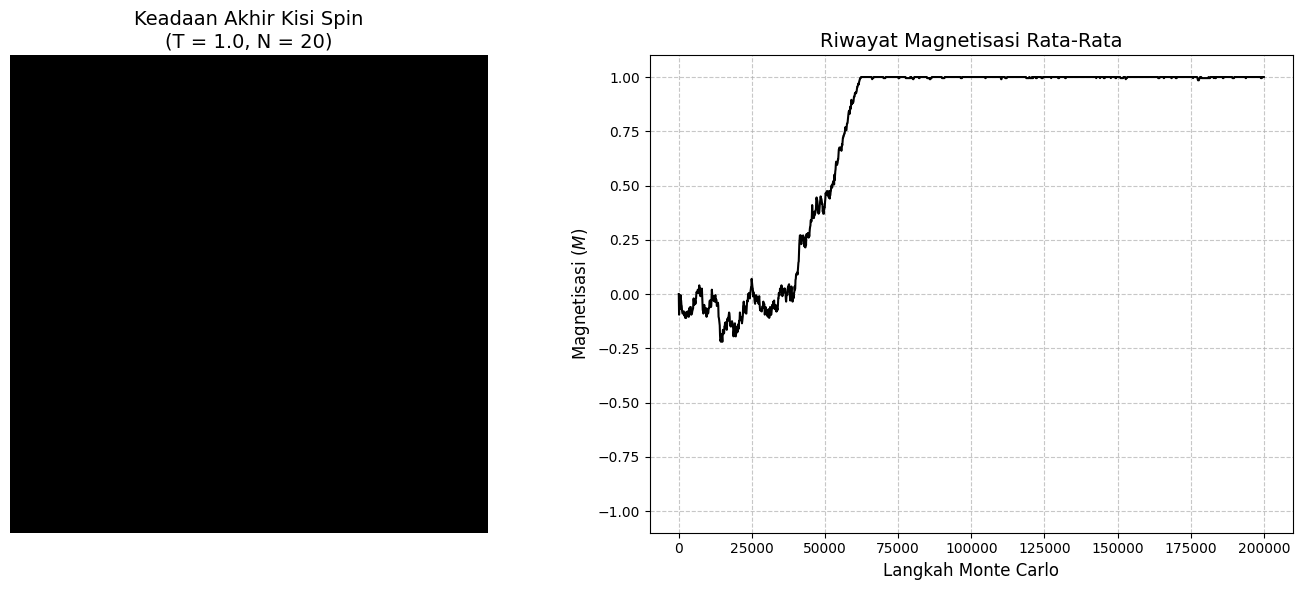

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Parameter Simulasi
# ==========================================
N = 20                 # Ukuran kisi N x N
T = 1.0                # Suhu sistem (T < Tc, dengan Tc ≈ 2.269)
MC_STEPS = 200000      # Total langkah Monte Carlo
RECORD_INTERVAL = 100  # Interval pengambilan sampel makrostate

# ==========================================
# Inisialisasi Sistem
# ==========================================
# Hot Start: Keadaan awal acak untuk merepresentasikan entropi maksimum (T -> tak hingga)
grid = np.random.choice([-1, 1], size=(N, N))

# Array penampung data
magnetization_history = []
time_steps = []

def calculate_magnetization(config):
    """Menghitung magnetisasi rata-rata sistem"""
    return np.sum(config) / (N * N)

# Catat keadaan awal
magnetization_history.append(calculate_magnetization(grid))
time_steps.append(0)

# Pra-kalkulasi probabilitas Boltzmann (Eksponensial) untuk optimasi kecepatan
# Perubahan energi (dE) pada kisi persegi hanya memiliki 5 kemungkinan nilai: -8, -4, 0, 4, 8 (dengan J=1)
exp_dE = {dE: np.exp(-dE / T) for dE in [-8, -4, 0, 4, 8]}

# ==========================================
# Loop Algoritma Metropolis-Hastings
# ==========================================
for step in range(1, MC_STEPS + 1):
    # 1. Pilih koordinat spin secara acak
    i, j = np.random.randint(0, N, size=2)

    # 2. Terapkan Syarat Batas Periodik (Periodic Boundary Conditions / PBC)
    spin = grid[i, j]
    neighbors = (grid[(i + 1) % N, j] +
                 grid[(i - 1) % N, j] +
                 grid[i, (j + 1) % N] +
                 grid[i, (j - 1) % N])

    # 3. Hitung perubahan energi jika spin ini dibalik (dE = 2 * S_i * Sum(S_j))
    dE = 2 * spin * neighbors

    # 4. Kriteria Penerimaan Metropolis
    # Jika energi turun (dE <= 0) ATAU probabilitas termal memenuhi syarat
    if dE <= 0 or np.random.rand() < exp_dE[dE]:
        grid[i, j] *= -1  # Balik orientasi spin

    # 5. Sampling data makroskopik
    if step % RECORD_INTERVAL == 0:
        magnetization_history.append(calculate_magnetization(grid))
        time_steps.append(step)

# ==========================================
# Visualisasi Data
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Keadaan Akhir Kisi (Domain Magnetik)
im = axes[0].imshow(grid, cmap='binary', vmin=-1, vmax=1)
axes[0].set_title(f'Keadaan Akhir Kisi Spin\n(T = {T}, N = {N})', fontsize=14)
axes[0].axis('off')

# Plot 2: Riwayat Magnetisasi
axes[1].plot(time_steps, magnetization_history, color='black', linewidth=1.5)
axes[1].set_title('Riwayat Magnetisasi Rata-Rata', fontsize=14)
axes[1].set_xlabel('Langkah Monte Carlo', fontsize=12)
axes[1].set_ylabel('Magnetisasi ($M$)', fontsize=12)
axes[1].set_ylim(-1.1, 1.1)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## **Hasil Analisis**

Pada suhu
𝑇 =
1.0
, sistem berada di bawah suhu kritis (
𝑇
𝑐
≈
2.27
), sehingga pengaruh interaksi antar-spin lebih kuat dibandingkan energi termal. Hal ini membuat spin cenderung tersusun searah dan membentuk domain besar yang seragam. Magnetisasi rata-rata bernilai jauh dari nol, menandakan adanya magnetisasi spontan. Kondisi tersebut menunjukkan bahwa sistem berada dalam fase feromagnetik, yaitu fase ketika sebagian besar spin teratur dengan arah yang sama.